In [1]:
import os
import mne
import json
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
files = [x for x in os.listdir('/mnt/s3-data2/amiftakhova/eeg_ti/resampled/') if 'TI' in x]
persons = [x[3:5] for x in files]

list_epochs = []
for p in persons:
    epoch = mne.read_epochs(f'/mnt/s3-data2/amiftakhova/eeg_ti/resampled/TI_{p}.fif', verbose=False)
    list_epochs.append(epoch)

list_epochs[13] = list_epochs[13].filter(1, 30, verbose=False)

list_labels = []
for id, epochs in enumerate(list_epochs):
    list_labels.append(epochs.events[:, -1] - 2)

In [15]:
# get sampling rate
sampling_rate = list_epochs[0].info['sfreq']
print(sampling_rate)

500.0


In [17]:
id = 0
epochs = list_epochs[id]

freqs = np.logspace(*np.log10([1, 30]), num=30)
n_cycles = freqs / 2.
tfr = mne.time_frequency.tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles,
                                       return_itc=False, average=False, n_jobs=8)
power = tfr.data
power = (power - power.min(axis=(0, 1, 3), keepdims=True)) / \
        (power.max(axis=(0, 1, 3), keepdims=True) - power.min(axis=(0, 1, 3), keepdims=True))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    5.3s finished
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 122 out of 127 | elapsed:   13.0s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 127 out of 127 | elapsed:   13.3s finished


Not setting metadata


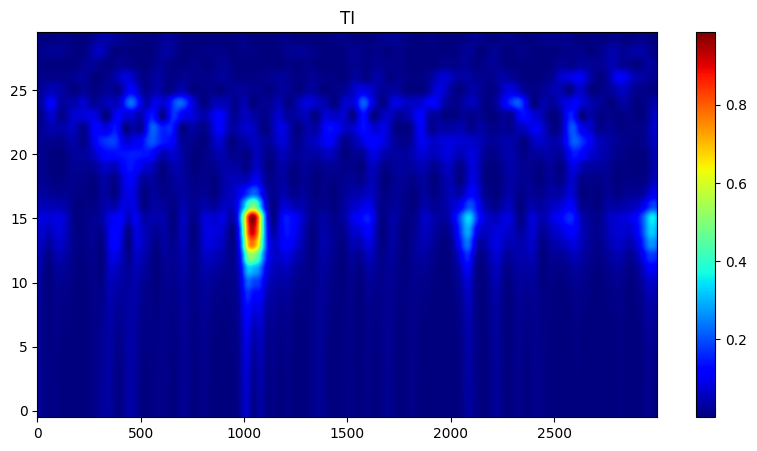

In [18]:
# plot the spectrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(power[0, 0], aspect='auto', origin='lower', cmap='jet')
plt.colorbar()
plt.title('TI')
plt.show()


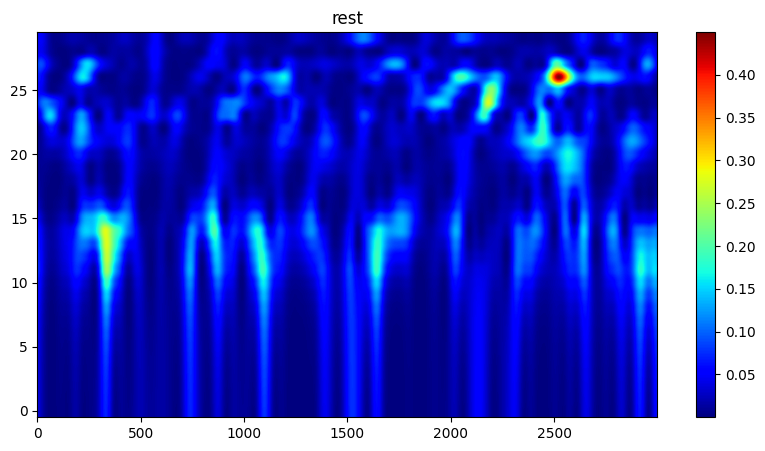

In [24]:
plt.figure(figsize=(10, 5))
plt.imshow(power[2, 0], aspect='auto', origin='lower', cmap='jet')
plt.colorbar()
plt.title('rest')
plt.show()


In [20]:
# to reduce the computation time, we can use only a subset of channels
# also you can reduce the number of frequencies and sampling rate
# the sampling rate could be regulated as epochs = epochs.resample(new_sampling_rate)
id = 0
epochs = list_epochs[id]

standard_1020 = ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T7', 'T8', 'P7', 'P8', 'Pz', 'P3', 'P4', 'O1', 'O2']
around_c3 = ['C3', 'C1', 'C5', 'FC3', 'CP3', 'FCC5h', 'FCC3h', 'CCP5h', 'CCP3h']

freqs = np.logspace(*np.log10([1, 30]), num=30)
n_cycles = freqs / 2.
tfr = mne.time_frequency.tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles,
                                    return_itc=False, average=False, picks=around_c3, n_jobs=8)
power = tfr.data
power = (power - power.min(axis=(0, 1, 3), keepdims=True)) / \
        (power.max(axis=(0, 1, 3), keepdims=True) - power.min(axis=(0, 1, 3), keepdims=True))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    6.8s finished
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:    7.8s remaining:    9.7s
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed:    7.8s remaining:    3.9s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    7.9s finished


Not setting metadata


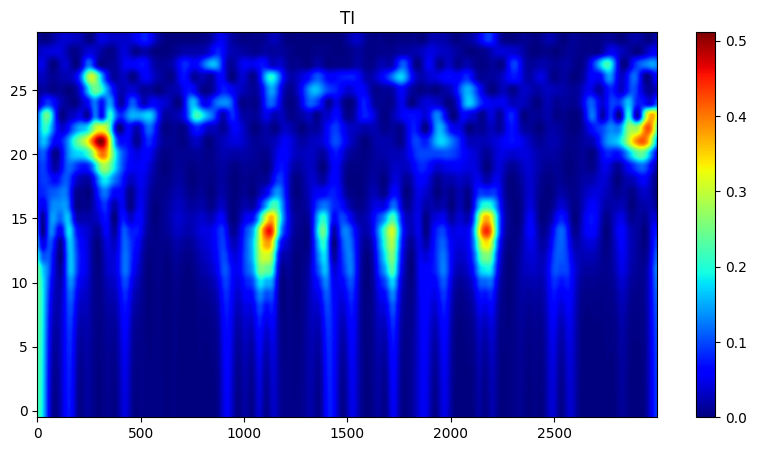

In [21]:
plt.figure(figsize=(10, 5))
plt.imshow(power[0, 0], aspect='auto', origin='lower', cmap='jet')
plt.colorbar()
plt.title('TI')
plt.show()

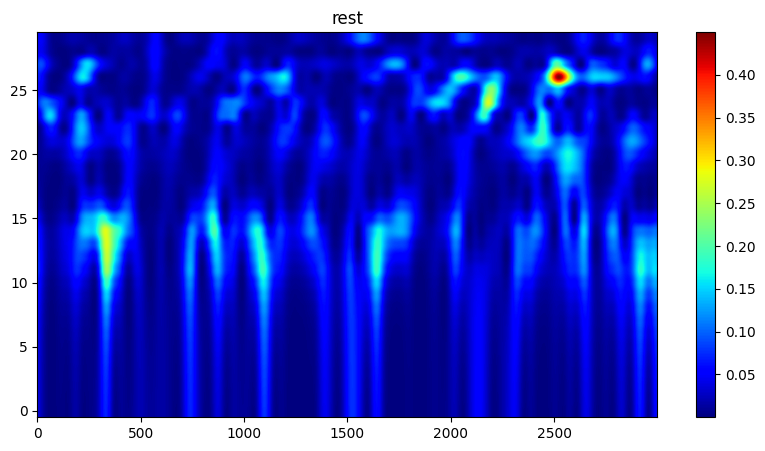

In [25]:
plt.figure(figsize=(10, 5))
plt.imshow(power[2, 0], aspect='auto', origin='lower', cmap='jet')
plt.colorbar()
plt.title('rest')
plt.show()
